# 08 — Causalidade de Granger por grupos

Resultados executados, com comparação total × pré-pandemia. A inferência é condicional ao modelo, não causalidade estrutural.

## Especificação, seleção e inferência



São sistemas bivariados independentes: uma série de desastre por vez + inadimplência nacional. Não condicionam simultaneamente às demais categorias ou à economia. Três especificações: (1) primeiras diferenças + constante e 11 dummies (janeiro referência); (2) mesmas diferenças + constante; (3) diferença sazonal das primeiras diferenças + constante. Dummies permitem médias distintas para cada mês; não removem automaticamente correlação residual ou mudanças estruturais.

Cada equação é estimada por OLS. Granger compara o modelo irrestrito com outro que retira **somente** as p defasagens da variável causadora. Constante, dummies e defasagens próprias permanecem nos dois modelos, na mesma amostra. Testa-se conjuntamente H0: todos os coeficientes retirados são zero. O F tem p graus de liberdade no numerador e n − q no denominador. A hipótese secundária inverte causa e alvo; não significa que inadimplência provoque fenômenos naturais.

Máximo de 12 meses, limitado por `n−p−q ≥ 30` e `n−p ≥ 3q`, com `q=2p+12` (dummies) ou `2p+1`. Isso resulta em máximo 12/6 para total/pré com dummies, 12/11 sem dummies e 12/9 na robustez. AIC/BIC usam amostra comum dentro de cada categoria/período/especificação (início no lag máximo). Critérios: `log det(Σ_ML) + penalidade * 2q/n`, penalidade 2 no AIC e log(n) no BIC. Os modelos escolhidos são reajustados com toda a amostra disponível para aquela ordem. BIC é referência; AIC é comparação.

Para reproduzir a regra do notebook 06, a seleção para o **teste de Granger** é restrita a ordens positivas, 1…máximo. Também é reportado o ótimo incluindo p=0. Se este for zero, não há defasagens cruzadas a testar no modelo irrestritamente preferido; o teste em ordem positiva é identificado como condicionado à exigência de dinâmica e excluído da síntese favorável. Não se inventa p-valor para VAR(0). Designs singulares/inviáveis são registrados. A sensibilidade contém todas as ordens positivas estimáveis, sem escolher retrospectivamente o menor p-valor.

## Diagnósticos e múltiplos testes

Para AIC **e** BIC: estabilidade pelos autovalores da matriz companheira (módulo <1); Portmanteau multivariado ajustado com horizonte maior que p; Ljung–Box auxiliar por equação com ajuste de 2p parâmetros dinâmicos e horizonte >2p; ACF(12/24), Jarque–Bera e Breusch–Pagan. Portmanteau é o diagnóstico primário de autocorrelação do sistema; testes residuais são aproximações assintóticas, particularmente limitadas nas amostras menores e com determinísticas. Limites ±1,96/√n da ACF são uma triagem pontual, não bandas simultâneas nem teste formal de raiz sazonal.

F clássico requer hipóteses sobre erros. Reportam-se também Wald-F HC3 e HAC com 12 lags e correção de amostra como sensibilidades; não corrigem um modelo dinâmico mal especificado. Significância com autocorrelação/instabilidade não é tratada como confirmação robusta.

**Famílias BH dos modelos selecionados:** uma família por direção; cada uma inclui todas as categorias (total, grupos e tipologias), os dois períodos, as três especificações e as ordens selecionadas por AIC/BIC. Um mesmo modelo escolhido por ambos critérios entra uma só vez. Essa família ampla evita fragmentar a correção em dezenas de pequenos grupos favoráveis. Os p-valores ajustados são unidos novamente às duas linhas dos critérios. Também é fornecido Benjamini–Yekutieli (BY), conservador sob dependência arbitrária, pois categorias e períodos se sobrepõem. BH é a referência solicitada; sua garantia formal pressupõe independência ou dependência positiva apropriada, não verificada aqui.

**Famílias da sensibilidade:** separadas das anteriores, uma por direção, contendo todos os lags, categorias, períodos e especificações. Esse ajuste não é intercambiável com o BH dos selecionados. Os p-valores permanecem exploratórios: a correção não elimina incerteza pós-seleção da ordem nem especificação incorreta.

A coluna “Evidência com diagnósticos favoráveis” exige BH <5%, HAC12 <5%, estabilidade, Portmanteau ≥5%, ausência de pico ACF12 na equação-alvo, ADF/KPSS convergentes nas duas séries e ótimo incluindo zero diferente de zero. Não é prova de robustez universal. Consistência entre critérios, especificações e períodos é apresentada separadamente. Os períodos se sobrepõem: concordância não é replicação independente e diferenças de significância não são teste formal de mudança de efeito.

Granger indica precedência/conteúdo preditivo condicionado à especificação; o F conjunto não informa o sinal do efeito. Não permite concluir que desastres aumentam inadimplência nem estabelecer causalidade estrutural. Contagem não mede intensidade, perdas ou população afetada. A escala nacional pode ocultar efeitos locais e inclui tipologias não estritamente climáticas (p.ex., doenças infecciosas e barragens), preservadas conforme a fonte.



In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0,str(ROOT/'src'))
from apresentacao_categorias import *


In [2]:
series=pd.read_parquet(ROOT/'data/processed/series_categorias.parquet')
meta=pd.read_json(ROOT/'data/processed/categorias_meta.json')
cobertura=ler('cobertura');testes=ler('estacionariedade')

## Cálculo conjunto para controlar multiplicidade

Executamos total, grupos **e tipologias** aqui para que a família BH permaneça completa. O notebook 09 apresenta o detalhamento das tipologias a partir dessa mesma execução.

In [3]:
resultados, sensibilidade, criterios, diagnosticos, inviaveis = executar_granger(series,meta,cobertura,testes)
comparacao=consistencia(resultados)

Total (2013–2024) Total nacional
Total (2013–2024) Grupo | Climatológico
Total (2013–2024) Grupo | Hidrológico
Total (2013–2024) Grupo | Meteorológico
Total (2013–2024) Grupo | Outros
Total (2013–2024) Tipologia | Alagamentos
Total (2013–2024) Tipologia | Chuvas Intensas
Total (2013–2024) Tipologia | Doenças infecciosas
Total (2013–2024) Tipologia | Enxurradas
Total (2013–2024) Tipologia | Erosão
Total (2013–2024) Tipologia | Estiagem e Seca
Total (2013–2024) Tipologia | Granizo
Total (2013–2024) Tipologia | Incêndio Florestal
Total (2013–2024) Tipologia | Inundações
Total (2013–2024) Tipologia | Movimento de Massa
Total (2013–2024) Tipologia | Onda de Calor e Baixa Umidade
Total (2013–2024) Tipologia | Onda de Frio
Total (2013–2024) Tipologia | Outros
Total (2013–2024) Tipologia | Rompimento/Colapso de barragens
Total (2013–2024) Tipologia | Tornado
Total (2013–2024) Tipologia | Vendavais e Ciclones
Pré-pandemia (até jan/2020) Total nacional
Pré-pandemia (até jan/2020) Grupo | Climato

/root/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/root/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/root/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/root/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/root/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self.

In [4]:
tabela(resultados.groupby(['Período','Nível','Direção'])[['Significativo nominal','Significativo BH','Evidência com diagnósticos favoráveis']].sum().reset_index())
tabela(inviaveis)

,Período,Nível,Direção,Significativo nominal,Significativo BH,Evidência com diagnósticos favoráveis
0,Pré-pandemia (até jan/2020),Grupo,Desastres → inadimplência,4,0,0
1,Pré-pandemia (até jan/2020),Grupo,Inadimplência → desastres,7,2,0
2,Pré-pandemia (até jan/2020),Referência,Desastres → inadimplência,1,0,0
3,Pré-pandemia (até jan/2020),Referência,Inadimplência → desastres,4,1,0
4,Pré-pandemia (até jan/2020),Tipologia,Desastres → inadimplência,9,0,0
5,Pré-pandemia (até jan/2020),Tipologia,Inadimplência → desastres,15,0,0
6,Total (2013–2024),Grupo,Desastres → inadimplência,2,0,0
7,Total (2013–2024),Grupo,Inadimplência → desastres,7,1,0
8,Total (2013–2024),Referência,Desastres → inadimplência,0,0,0
9,Total (2013–2024),Referência,Inadimplência → desastres,3,1,0


,Período,Chave,Nível,Categoria,Motivo
0,Pré-pandemia (até jan/2020),Tipologia | Onda de Calor e Baixa Umidade,Tipologia,Onda de Calor e Baixa Umidade,Constante ou rara (<12 meses positivos ou <24 protocolos); in...
1,Pré-pandemia (até jan/2020),Tipologia | Rompimento/Colapso de barragens,Tipologia,Rompimento/Colapso de barragens,Constante ou rara (<12 meses positivos ou <24 protocolos); in...


## Análise detalhada

As tabelas contêm as duas direções e os dois critérios em todas as especificações. Os gráficos de sensibilidade mostram p-valores originais; os ajustados estão nas tabelas completas e no HTML. Não interpretar um mínimo isolado como o resultado principal.

### Total nacional — Total (2013–2024)

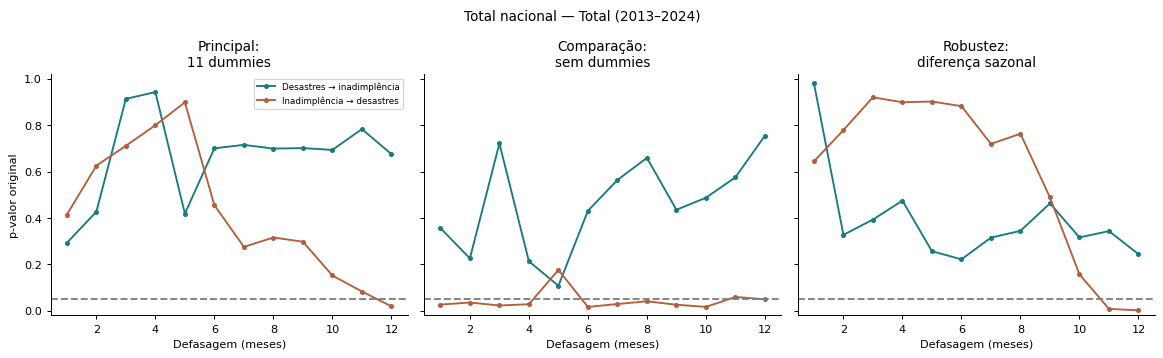

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
0,Principal: 11 dummies,AIC,Desastres → inadimplência,2,0.857574,0.426670,0.830090,1.000000,0.475217,2.765052e-01,141,2,125,2
1,Principal: 11 dummies,AIC,Inadimplência → desastres,2,0.471250,0.625326,0.823518,1.000000,0.636156,6.074412e-01,141,2,125,2
2,Principal: 11 dummies,BIC,Desastres → inadimplência,1,1.119057,0.292114,0.830090,1.000000,0.300295,2.821019e-01,142,1,128,1
3,Principal: 11 dummies,BIC,Inadimplência → desastres,1,0.672659,0.413651,0.679775,1.000000,0.479254,2.947904e-01,142,1,128,1
4,Comparação: sem dummies,AIC,Desastres → inadimplência,7,0.831134,0.563449,0.847699,1.000000,0.646352,2.100418e-01,136,7,121,7
5,Comparação: sem dummies,AIC,Inadimplência → desastres,7,2.337400,0.028432,0.171772,1.000000,0.004978,1.384687e-06,136,7,121,7
6,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.856804,0.356239,0.830090,1.000000,0.298962,4.126708e-01,142,1,139,1
7,Comparação: sem dummies,BIC,Inadimplência → desastres,1,5.058023,0.026085,0.170276,1.000000,0.053388,1.815907e-02,142,1,139,1
8,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,1.279585,0.243591,0.783005,1.000000,0.198432,5.375207e-09,119,12,94,12
9,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,3.005538,0.001342,0.045036,0.271971,0.002289,4.649072e-07,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
0,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.665507,7.906045e-02,2.811274e-01,-0.078720,False,7.184307e-10,0.133679,Estacionária: convergente,Estacionária: convergente
1,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.665507,7.906045e-02,6.311811e-02,0.108236,False,3.902099e-01,0.560359,Estacionária: convergente,Estacionária: convergente
2,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.451263,9.766746e-03,1.358283e-01,-0.054826,False,5.575511e-06,0.518457,Estacionária: convergente,Estacionária: convergente
3,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.451263,9.766746e-03,2.079077e-02,0.062770,False,9.382272e-02,0.646150,Estacionária: convergente,Estacionária: convergente
4,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.946456,2.614128e-02,2.925785e-03,0.187098,True,5.957322e-17,0.381341,Estacionária: convergente,Estacionária: convergente
5,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.946456,2.614128e-02,8.027764e-04,0.093205,False,7.047708e-01,0.181504,Estacionária: convergente,Estacionária: convergente
6,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.328733,1.741691e-11,8.741104e-13,0.391060,True,1.692384e-04,0.197880,Estacionária: convergente,Estacionária: convergente
7,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.328733,1.741691e-11,5.142619e-03,0.189092,True,8.701195e-01,0.079378,Estacionária: convergente,Estacionária: convergente
8,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.968166,7.267171e-04,7.138796e-06,-0.130978,False,4.525939e-01,0.978857,Estacionária: convergente,Estacionária: convergente
9,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.968166,7.267171e-04,3.364159e-06,-0.092057,False,1.581577e-02,0.486663,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 2, p=0.4267, BH=0.8301, n=141; BIC: lag 1, p=0.2921, BH=0.8301, n=142.

**Comparação: sem dummies** — AIC: lag 7, p=0.5634, BH=0.8477, n=136; BIC: lag 1, p=0.3562, BH=0.8301, n=142.

**Robustez: diferença sazonal** — AIC: lag 12, p=0.2436, BH=0.783, n=119; BIC: lag 2, p=0.3268, BH=0.8301, n=129.

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 3 nominais e 1 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 10/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Total nacional — Pré-pandemia (até jan/2020)

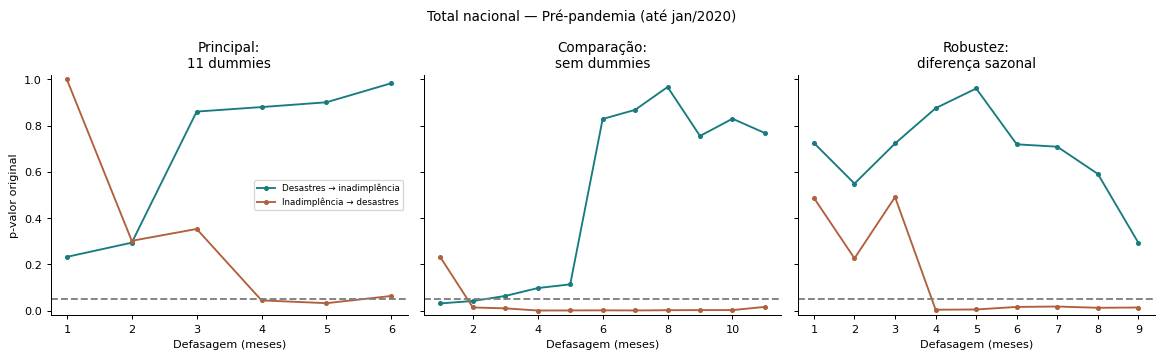

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
252,Principal: 11 dummies,AIC,Desastres → inadimplência,4,0.295306,0.879898,0.949633,1.000000,0.898935,1.769508e-01,80,4,60,4
253,Principal: 11 dummies,AIC,Inadimplência → desastres,4,2.610919,0.044207,0.212012,1.000000,0.089852,5.790808e-02,80,4,60,4
254,Principal: 11 dummies,BIC,Desastres → inadimplência,2,1.247991,0.293766,0.830090,1.000000,0.371266,1.835608e-01,82,2,66,2
255,Principal: 11 dummies,BIC,Inadimplência → desastres,2,1.220038,0.301789,0.581315,1.000000,0.313330,8.313658e-02,82,2,66,2
256,Comparação: sem dummies,AIC,Desastres → inadimplência,7,0.447928,0.867848,0.949633,1.000000,0.877501,6.651885e-02,77,7,62,7
257,Comparação: sem dummies,AIC,Inadimplência → desastres,7,4.241460,0.000701,0.038581,0.232985,0.000398,6.529320e-15,77,7,62,7
258,Comparação: sem dummies,BIC,Desastres → inadimplência,2,3.313042,0.041662,0.362610,1.000000,0.028366,2.929082e-02,82,2,77,2
259,Comparação: sem dummies,BIC,Inadimplência → desastres,2,4.545004,0.013621,0.123114,0.743475,0.005218,2.685598e-03,82,2,77,2
260,Robustez: diferença sazonal,AIC,Desastres → inadimplência,4,0.302811,0.874945,0.949633,1.000000,0.858322,1.367173e-01,68,4,59,4
261,Robustez: diferença sazonal,AIC,Inadimplência → desastres,4,4.324819,0.003905,0.076474,0.461818,0.001322,2.518696e-09,68,4,59,4


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
252,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.826432,0.140021,0.014336,-0.201204,False,0.015987,0.572646,Inconclusiva: nenhum rejeita,Estacionária: convergente
253,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.826432,0.140021,0.161096,0.079153,False,0.949078,0.191256,Inconclusiva: nenhum rejeita,Estacionária: convergente
254,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.649277,0.020836,0.004187,-0.169748,False,0.414673,0.813281,Inconclusiva: nenhum rejeita,Estacionária: convergente
255,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.649277,0.020836,0.349107,0.054274,False,0.554937,0.467512,Inconclusiva: nenhum rejeita,Estacionária: convergente
256,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.953176,0.376737,0.045253,0.067486,False,0.123634,0.440829,Inconclusiva: nenhum rejeita,Estacionária: convergente
257,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.953176,0.376737,0.051692,0.097871,False,0.588289,0.294899,Inconclusiva: nenhum rejeita,Estacionária: convergente
258,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.689207,0.000175,0.000010,0.282764,True,0.105515,0.842391,Inconclusiva: nenhum rejeita,Estacionária: convergente
259,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.689207,0.000175,0.116310,0.200942,False,0.727860,0.538150,Inconclusiva: nenhum rejeita,Estacionária: convergente
260,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.747623,0.008060,0.002292,-0.394511,True,0.990025,0.825266,Inconclusiva: nenhum rejeita,Estacionária: convergente
261,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.747623,0.008060,0.082170,-0.211089,False,0.565781,0.748418,Inconclusiva: nenhum rejeita,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 4, p=0.8799, BH=0.9496, n=80; BIC: lag 2, p=0.2938, BH=0.8301, n=82.

**Comparação: sem dummies** — AIC: lag 7, p=0.8678, BH=0.9496, n=77; BIC: lag 2, p=0.04166, BH=0.3626, n=82.

**Robustez: diferença sazonal** — AIC: lag 4, p=0.8749, BH=0.9496, n=68; BIC: lag 2, p=0.5491, BH=0.8379, n=70 (ótimo incluindo zero: 0).

Na direção principal, 1/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 4 nominais e 1 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 8/12 linhas; 4 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Grupo | Climatológico — Total (2013–2024)

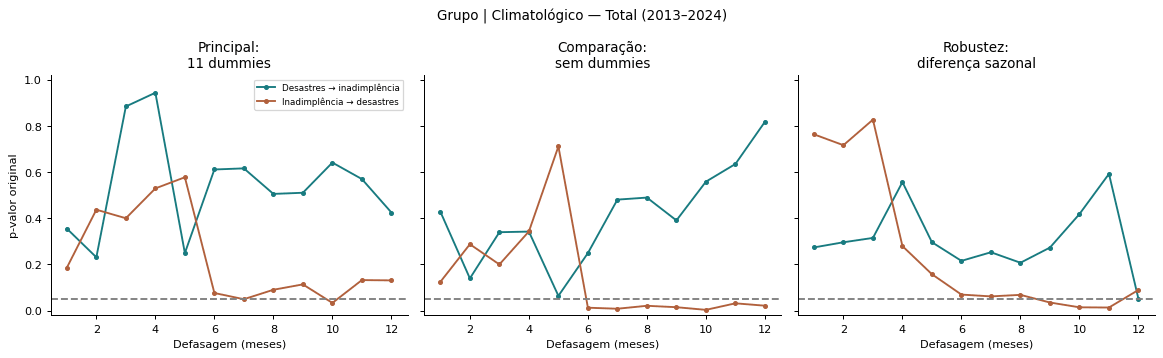

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
12,Principal: 11 dummies,AIC,Desastres → inadimplência,7,0.766889,0.616217,0.847699,1.000000,0.758521,6.253712e-01,136,7,110,7
13,Principal: 11 dummies,AIC,Inadimplência → desastres,7,2.098907,0.049454,0.223494,1.000000,0.144440,1.263890e-06,136,7,110,7
14,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.860911,0.355230,0.830090,1.000000,0.421332,5.121241e-01,142,1,128,1
15,Principal: 11 dummies,BIC,Inadimplência → desastres,1,1.767419,0.186066,0.435631,1.000000,0.245407,7.027147e-02,142,1,128,1
16,Comparação: sem dummies,AIC,Desastres → inadimplência,7,0.936829,0.480855,0.837319,1.000000,0.267978,1.070603e-02,136,7,121,7
17,Comparação: sem dummies,AIC,Inadimplência → desastres,7,2.874366,0.008219,0.112725,0.680739,0.000728,1.429748e-13,136,7,121,7
18,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.630864,0.428393,0.830090,1.000000,0.461863,6.325156e-01,142,1,139,1
19,Comparação: sem dummies,BIC,Inadimplência → desastres,1,2.386727,0.124643,0.364163,1.000000,0.159413,1.243718e-01,142,1,139,1
20,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,1.851407,0.050778,0.397765,1.000000,0.035769,4.371847e-09,119,12,94,12
21,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,1.655785,0.089562,0.323802,1.000000,0.133402,3.991780e-09,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
12,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.906605,1.902971e-01,7.259303e-02,-0.113055,False,2.271165e-12,0.047664,Estacionária: convergente,Estacionária: convergente
13,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.906605,1.902971e-01,3.902186e-02,-0.008901,False,4.508973e-01,0.722054,Estacionária: convergente,Estacionária: convergente
14,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.445973,3.550148e-04,1.515765e-01,-0.036946,False,4.213667e-07,0.458353,Estacionária: convergente,Estacionária: convergente
15,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.445973,3.550148e-04,1.801349e-05,0.087557,False,4.445388e-01,0.359808,Estacionária: convergente,Estacionária: convergente
16,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.945291,3.404450e-02,8.798337e-03,0.162065,False,2.061427e-18,0.265519,Estacionária: convergente,Estacionária: convergente
17,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.945291,3.404450e-02,1.019464e-02,0.089915,False,4.722947e-01,0.574868,Estacionária: convergente,Estacionária: convergente
18,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.327453,8.377106e-13,8.377886e-14,0.402070,True,2.127192e-04,0.136635,Estacionária: convergente,Estacionária: convergente
19,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.327453,8.377106e-13,1.606990e-06,0.228260,True,3.066654e-01,0.058464,Estacionária: convergente,Estacionária: convergente
20,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.969019,4.038296e-03,3.671197e-04,-0.099282,False,7.583890e-03,0.947646,Estacionária: convergente,Estacionária: convergente
21,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.969019,4.038296e-03,2.786216e-04,-0.134821,False,7.876594e-01,0.308833,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 7, p=0.6162, BH=0.8477, n=136; BIC: lag 1, p=0.3552, BH=0.8301, n=142.

**Comparação: sem dummies** — AIC: lag 7, p=0.4809, BH=0.8373, n=136; BIC: lag 1, p=0.4284, BH=0.8301, n=142.

**Robustez: diferença sazonal** — AIC: lag 12, p=0.05078, BH=0.3978, n=119; BIC: lag 1, p=0.2738, BH=0.8249, n=130.

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 2 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 10/12 linhas; 4 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Grupo | Climatológico — Pré-pandemia (até jan/2020)

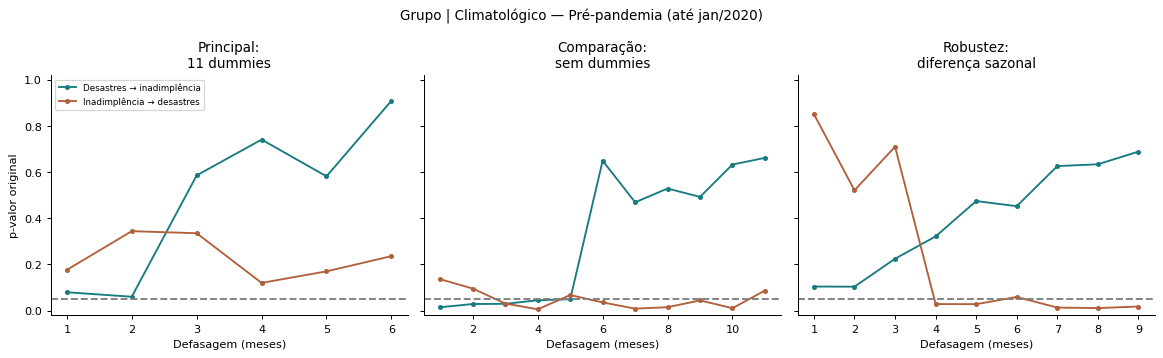

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
264,Principal: 11 dummies,AIC,Desastres → inadimplência,5,0.760769,0.581842,0.847699,1.000000,0.707853,4.937668e-02,79,5,57,5
265,Principal: 11 dummies,AIC,Inadimplência → desastres,5,1.617332,0.170151,0.420900,1.000000,0.286690,5.256685e-02,79,5,57,5
266,Principal: 11 dummies,BIC,Desastres → inadimplência,1,3.165601,0.079609,0.566911,1.000000,0.127183,1.648610e-01,83,1,69,1
267,Principal: 11 dummies,BIC,Inadimplência → desastres,1,1.864546,0.176536,0.432146,1.000000,0.202728,1.081041e-01,83,1,69,1
268,Comparação: sem dummies,AIC,Desastres → inadimplência,7,0.958379,0.469313,0.837319,1.000000,0.436483,2.652757e-03,77,7,62,7
269,Comparação: sem dummies,AIC,Inadimplência → desastres,7,3.013211,0.008636,0.112725,0.680739,0.000771,1.469799e-14,77,7,62,7
270,Comparação: sem dummies,BIC,Desastres → inadimplência,1,6.210426,0.014766,0.258566,1.000000,0.022388,1.066954e-01,83,1,80,1
271,Comparação: sem dummies,BIC,Inadimplência → desastres,1,2.270007,0.135838,0.375552,1.000000,0.118229,1.168958e-01,83,1,80,1
272,Robustez: diferença sazonal,AIC,Desastres → inadimplência,4,1.197579,0.321432,0.830090,1.000000,0.312082,1.131777e-01,68,4,59,4
273,Robustez: diferença sazonal,AIC,Inadimplência → desastres,4,2.918968,0.028545,0.171772,1.000000,0.064699,9.949873e-03,68,4,59,4


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
264,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.868930,1.810898e-02,2.920848e-02,-0.187419,False,0.063048,0.360797,Inconclusiva: nenhum rejeita,Estacionária: convergente
265,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.868930,1.810898e-02,3.657128e-03,-0.012484,False,0.076317,0.903613,Inconclusiva: nenhum rejeita,Estacionária: convergente
266,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.448521,2.994479e-04,2.340436e-03,-0.083555,False,0.575330,0.977924,Inconclusiva: nenhum rejeita,Estacionária: convergente
267,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.448521,2.994479e-04,1.410462e-02,0.038923,False,0.524655,0.479579,Inconclusiva: nenhum rejeita,Estacionária: convergente
268,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.964330,2.423866e-01,1.387188e-01,0.045642,False,0.574348,0.209611,Inconclusiva: nenhum rejeita,Estacionária: convergente
269,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.964330,2.423866e-01,1.019821e-02,0.113927,False,0.110174,0.875700,Inconclusiva: nenhum rejeita,Estacionária: convergente
270,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.316969,6.588510e-08,8.823359e-07,0.295969,True,0.550808,0.089901,Inconclusiva: nenhum rejeita,Estacionária: convergente
271,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.316969,6.588510e-08,3.247133e-05,0.269362,True,0.504792,0.270859,Inconclusiva: nenhum rejeita,Estacionária: convergente
272,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.809539,2.819843e-02,9.395123e-03,-0.362318,True,0.981539,0.798074,Inconclusiva: nenhum rejeita,Estacionária: convergente
273,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.809539,2.819843e-02,7.207850e-03,-0.151520,False,0.719539,0.750473,Inconclusiva: nenhum rejeita,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 5, p=0.5818, BH=0.8477, n=79; BIC: lag 1, p=0.07961, BH=0.5669, n=83.

**Comparação: sem dummies** — AIC: lag 7, p=0.4693, BH=0.8373, n=77; BIC: lag 1, p=0.01477, BH=0.2586, n=83.

**Robustez: diferença sazonal** — AIC: lag 4, p=0.3214, BH=0.8301, n=68; BIC: lag 1, p=0.1044, BH=0.5705, n=71.

Na direção principal, 1/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 2 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 10/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Grupo | Hidrológico — Total (2013–2024)

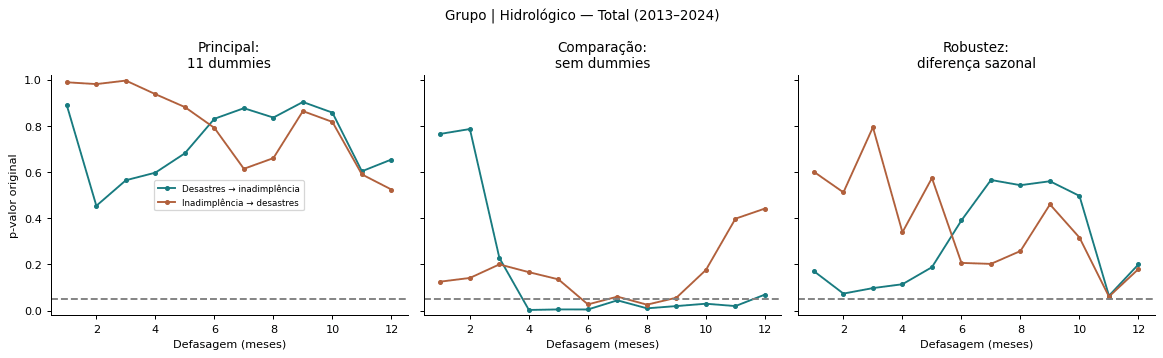

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
24,Principal: 11 dummies,AIC,Desastres → inadimplência,2,0.794452,0.454097,0.837319,1.0,0.496378,4.360184e-01,141,2,125,2
25,Principal: 11 dummies,AIC,Inadimplência → desastres,2,0.018920,0.981261,0.993048,1.0,0.979377,9.394245e-01,141,2,125,2
26,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.019551,0.889018,0.949633,1.0,0.886927,8.532204e-01,142,1,128,1
27,Principal: 11 dummies,BIC,Inadimplência → desastres,1,0.000188,0.989073,0.993300,1.0,0.990980,9.882877e-01,142,1,128,1
28,Comparação: sem dummies,AIC,Desastres → inadimplência,9,2.314216,0.019772,0.273314,1.0,0.008922,4.326867e-10,134,9,115,9
29,Comparação: sem dummies,AIC,Inadimplência → desastres,9,1.918230,0.055982,0.229486,1.0,0.141882,2.296335e-03,134,9,115,9
30,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.089282,0.765538,0.899508,1.0,0.742730,6.855395e-01,142,1,139,0
31,Comparação: sem dummies,BIC,Inadimplência → desastres,1,2.375572,0.125520,0.364163,1.0,0.210230,1.366993e-01,142,1,139,0
32,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,1.357619,0.200415,0.713599,1.0,0.436003,4.677902e-03,119,12,94,12
33,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,1.398977,0.180189,0.433738,1.0,0.119331,4.490738e-08,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
24,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.656461,1.023387e-01,1.951059e-01,-0.046373,False,5.145535e-07,0.125031,Estacionária: convergente,Estacionária: convergente
25,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.656461,1.023387e-01,8.411477e-03,-0.106540,False,9.845354e-09,0.222908,Estacionária: convergente,Estacionária: convergente
26,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.460729,1.825748e-02,1.641250e-01,-0.039353,False,1.639993e-06,0.481977,Estacionária: convergente,Estacionária: convergente
27,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.460729,1.825748e-02,2.545655e-04,-0.131928,False,1.531633e-06,0.134648,Estacionária: convergente,Estacionária: convergente
28,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.956797,4.541242e-02,8.731814e-03,0.106123,False,4.746868e-17,0.337329,Estacionária: convergente,Estacionária: convergente
29,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.956797,4.541242e-02,1.857099e-04,0.024803,False,3.418331e-01,0.138793,Estacionária: convergente,Estacionária: convergente
30,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.191546,6.634273e-14,1.400564e-14,0.407400,True,2.248079e-04,0.251414,Estacionária: convergente,Estacionária: convergente
31,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.191546,6.634273e-14,4.099218e-04,0.228852,True,6.533049e-02,0.022337,Estacionária: convergente,Estacionária: convergente
32,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.972707,3.185547e-04,2.326235e-06,-0.131314,False,6.020003e-01,0.903525,Estacionária: convergente,Estacionária: convergente
33,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.972707,3.185547e-04,8.221661e-10,-0.125913,False,6.031603e-01,0.155009,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 2, p=0.4541, BH=0.8373, n=141; BIC: lag 1, p=0.889, BH=0.9496, n=142.

**Comparação: sem dummies** — AIC: lag 9, p=0.01977, BH=0.2733, n=134; BIC: lag 1, p=0.7655, BH=0.8995, n=142 (ótimo incluindo zero: 0).

**Robustez: diferença sazonal** — AIC: lag 12, p=0.2004, BH=0.7136, n=119; BIC: lag 1, p=0.1709, BH=0.6739, n=130.

Na direção principal, 1/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 0 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 10/12 linhas; 4 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Grupo | Hidrológico — Pré-pandemia (até jan/2020)

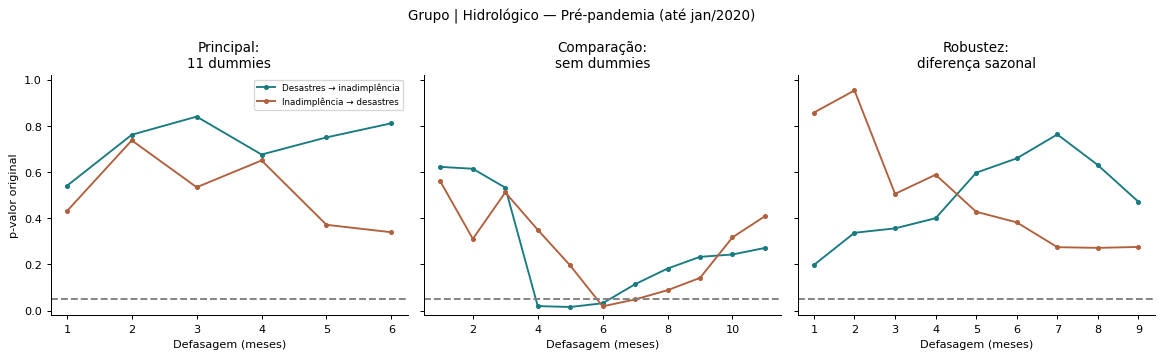

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
276,Principal: 11 dummies,AIC,Desastres → inadimplência,3,0.278980,0.840363,0.927162,1.000000,0.865681,6.177302e-01,81,3,63,3
277,Principal: 11 dummies,AIC,Inadimplência → desastres,3,0.736085,0.534415,0.789858,1.000000,0.608277,2.465172e-01,81,3,63,3
278,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.378852,0.540243,0.837887,1.000000,0.570730,2.354238e-01,83,1,69,0
279,Principal: 11 dummies,BIC,Inadimplência → desastres,1,0.628709,0.430547,0.702629,1.000000,0.536109,4.744208e-01,83,1,69,0
280,Comparação: sem dummies,AIC,Desastres → inadimplência,6,2.480498,0.031921,0.331134,1.000000,0.022433,2.142319e-07,78,6,65,6
281,Comparação: sem dummies,AIC,Inadimplência → desastres,6,2.764039,0.018666,0.132928,0.802743,0.034826,6.660339e-07,78,6,65,6
282,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.243882,0.622769,0.847699,1.000000,0.610578,5.670687e-01,83,1,80,0
283,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.343495,0.559469,0.796142,1.000000,0.701583,6.552044e-01,83,1,80,0
284,Robustez: diferença sazonal,AIC,Desastres → inadimplência,3,1.099119,0.356325,0.830090,1.000000,0.194200,2.219513e-02,69,3,62,3
285,Robustez: diferença sazonal,AIC,Inadimplência → desastres,3,0.786745,0.505865,0.768695,1.000000,0.544257,3.565645e-01,69,3,62,3


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
276,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.848014,3.711074e-01,2.096946e-01,-0.139154,False,0.021765,0.446954,Inconclusiva: nenhum rejeita,Estacionária: convergente
277,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.848014,3.711074e-01,1.214722e-01,-0.132124,False,0.000247,0.214431,Inconclusiva: nenhum rejeita,Estacionária: convergente
278,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.336411,2.177376e-01,5.877626e-03,-0.060866,False,0.839533,0.948085,Inconclusiva: nenhum rejeita,Estacionária: convergente
279,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.336411,2.177376e-01,2.254335e-01,-0.129377,False,0.000018,0.315620,Inconclusiva: nenhum rejeita,Estacionária: convergente
280,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.952246,8.477713e-01,4.019093e-02,0.006610,False,0.004881,0.975851,Inconclusiva: nenhum rejeita,Estacionária: convergente
281,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.952246,8.477713e-01,5.862259e-02,0.101974,False,0.019301,0.698644,Inconclusiva: nenhum rejeita,Estacionária: convergente
282,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.266344,7.522477e-07,3.439727e-09,0.373758,True,0.176115,0.602840,Inconclusiva: nenhum rejeita,Estacionária: convergente
283,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.266344,7.522477e-07,3.506941e-02,0.277105,True,0.030397,0.070611,Inconclusiva: nenhum rejeita,Estacionária: convergente
284,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.771452,1.186974e-02,2.778700e-02,-0.353026,True,0.898358,0.850969,Inconclusiva: nenhum rejeita,Estacionária: convergente
285,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.771452,1.186974e-02,1.700283e-04,-0.435356,True,0.013580,0.769238,Inconclusiva: nenhum rejeita,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 3, p=0.8404, BH=0.9272, n=81; BIC: lag 1, p=0.5402, BH=0.8379, n=83 (ótimo incluindo zero: 0).

**Comparação: sem dummies** — AIC: lag 6, p=0.03192, BH=0.3311, n=78; BIC: lag 1, p=0.6228, BH=0.8477, n=83 (ótimo incluindo zero: 0).

**Robustez: diferença sazonal** — AIC: lag 3, p=0.3563, BH=0.8301, n=69; BIC: lag 1, p=0.1979, BH=0.7136, n=71 (ótimo incluindo zero: 0).

Na direção principal, 1/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 1 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 6/12 linhas; 6 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Grupo | Meteorológico — Total (2013–2024)

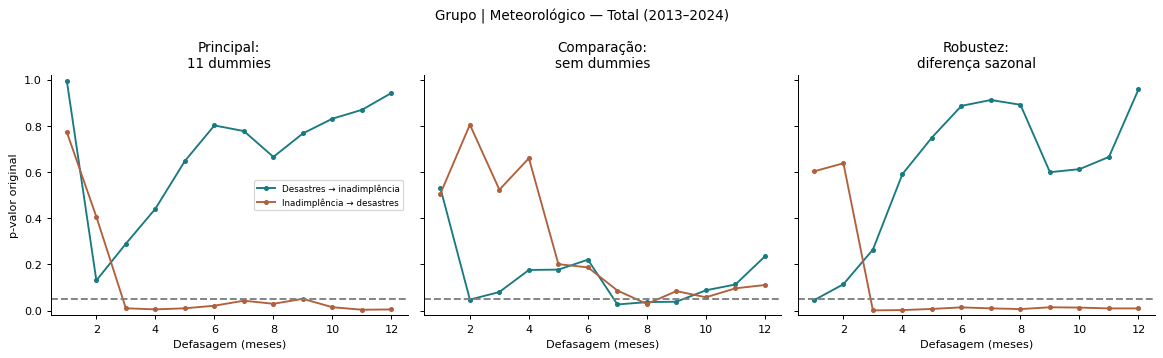

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
36,Principal: 11 dummies,AIC,Desastres → inadimplência,3,1.263964,0.289830,0.830090,1.000000,0.103822,3.148866e-02,140,3,122,3
37,Principal: 11 dummies,AIC,Inadimplência → desastres,3,3.932412,0.010178,0.113892,0.687783,0.047821,7.113153e-02,140,3,122,3
38,Principal: 11 dummies,BIC,Desastres → inadimplência,3,1.263964,0.289830,0.830090,1.000000,0.103822,3.148866e-02,140,3,122,3
39,Principal: 11 dummies,BIC,Inadimplência → desastres,3,3.932412,0.010178,0.113892,0.687783,0.047821,7.113153e-02,140,3,122,3
40,Comparação: sem dummies,AIC,Desastres → inadimplência,9,2.061523,0.038645,0.362610,1.000000,0.091318,1.194340e-04,134,9,115,9
41,Comparação: sem dummies,AIC,Inadimplência → desastres,9,1.754236,0.084646,0.310811,1.000000,0.052666,3.059640e-07,134,9,115,9
42,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.394385,0.531034,0.837887,1.000000,0.552754,2.720401e-01,142,1,139,1
43,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.444038,0.506284,0.768695,1.000000,0.701426,6.331534e-01,142,1,139,1
44,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,0.405626,0.958177,0.980763,1.000000,0.975850,3.407328e-02,119,12,94,12
45,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,2.392768,0.009594,0.112725,0.680739,0.079379,8.431630e-06,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
36,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.735337,5.838417e-02,4.803009e-01,-0.080078,False,2.416450e-19,0.015889,Estacionária: convergente,Estacionária: convergente
37,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.735337,5.838417e-02,6.013590e-04,-0.081943,False,3.928514e-03,0.000009,Estacionária: convergente,Estacionária: convergente
38,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.735337,5.838417e-02,4.803009e-01,-0.080078,False,2.416450e-19,0.015889,Estacionária: convergente,Estacionária: convergente
39,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.735337,5.838417e-02,6.013590e-04,-0.081943,False,3.928514e-03,0.000009,Estacionária: convergente,Estacionária: convergente
40,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.951788,1.397756e-02,7.846091e-03,0.131593,False,1.183446e-15,0.215978,Estacionária: convergente,Estacionária: convergente
41,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.951788,1.397756e-02,6.803907e-02,0.008981,False,3.143009e-03,0.001144,Estacionária: convergente,Estacionária: convergente
42,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.396980,1.086186e-12,7.461879e-13,0.390827,True,6.901621e-04,0.176781,Estacionária: convergente,Estacionária: convergente
43,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.396980,1.086186e-12,1.040759e-02,0.162189,False,1.940806e-03,0.000034,Estacionária: convergente,Estacionária: convergente
44,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.967274,2.021188e-04,3.242595e-06,-0.137423,False,5.904340e-02,0.929310,Estacionária: convergente,Estacionária: convergente
45,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.967274,2.021188e-04,1.045426e-07,-0.284987,True,1.248197e-02,0.786305,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 3, p=0.2898, BH=0.8301, n=140; BIC: lag 3, p=0.2898, BH=0.8301, n=140.

**Comparação: sem dummies** — AIC: lag 9, p=0.03864, BH=0.3626, n=134; BIC: lag 1, p=0.531, BH=0.8379, n=142.

**Robustez: diferença sazonal** — AIC: lag 12, p=0.9582, BH=0.9808, n=119; BIC: lag 3, p=0.2646, BH=0.8181, n=128.

Na direção principal, 1/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 4 nominais e 1 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 8/12 linhas; 4 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Grupo | Meteorológico — Pré-pandemia (até jan/2020)

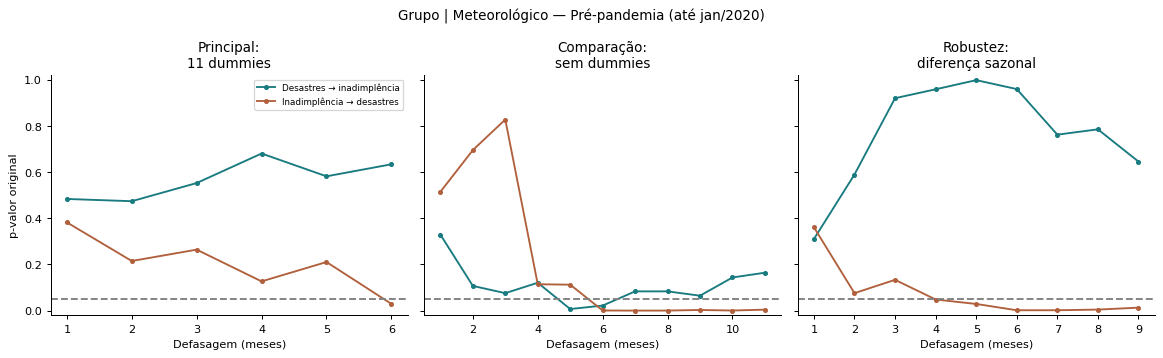

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
288,Principal: 11 dummies,AIC,Desastres → inadimplência,6,0.721688,0.633900,0.847699,1.000000,0.750605,1.411626e-03,78,6,54,6
289,Principal: 11 dummies,AIC,Inadimplência → desastres,6,2.567037,0.029238,0.171772,1.000000,0.198384,5.526828e-06,78,6,54,6
290,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.495782,0.483729,0.837319,1.000000,0.504617,2.537730e-01,83,1,69,1
291,Principal: 11 dummies,BIC,Inadimplência → desastres,1,0.773158,0.382294,0.675913,1.000000,0.509807,4.717269e-01,83,1,69,1
292,Comparação: sem dummies,AIC,Desastres → inadimplência,11,1.492182,0.164229,0.665411,1.000000,0.006031,1.855143e-20,73,11,50,11
293,Comparação: sem dummies,AIC,Inadimplência → desastres,11,2.960018,0.004296,0.077667,0.469024,0.036934,1.757599e-12,73,11,50,11
294,Comparação: sem dummies,BIC,Desastres → inadimplência,6,2.679405,0.021914,0.286102,1.000000,0.010458,1.252538e-08,78,6,65,6
295,Comparação: sem dummies,BIC,Inadimplência → desastres,6,4.551597,0.000652,0.038581,0.232985,0.003108,1.002262e-09,78,6,65,6
296,Robustez: diferença sazonal,AIC,Desastres → inadimplência,6,0.243999,0.959637,0.980763,1.000000,0.918656,4.657803e-02,66,6,53,6
297,Robustez: diferença sazonal,AIC,Inadimplência → desastres,6,4.165065,0.001680,0.049363,0.298102,0.006682,7.536765e-07,66,6,53,6


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
288,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.880533,0.006378,0.001262,-0.266694,True,0.001001,0.877292,Inconclusiva: nenhum rejeita,Estacionária: convergente
289,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.880533,0.006378,0.004010,0.100807,False,0.536754,0.246949,Inconclusiva: nenhum rejeita,Estacionária: convergente
290,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.668086,0.000666,0.004162,-0.102918,False,0.705251,0.961545,Inconclusiva: nenhum rejeita,Estacionária: convergente
291,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.668086,0.000666,0.002602,-0.028396,False,0.533957,0.034864,Inconclusiva: nenhum rejeita,Estacionária: convergente
292,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.980975,0.118800,0.034563,-0.088904,False,0.000013,0.650780,Inconclusiva: nenhum rejeita,Estacionária: convergente
293,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.980975,0.118800,0.000315,-0.101946,False,0.691630,0.045034,Inconclusiva: nenhum rejeita,Estacionária: convergente
294,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.959539,0.006307,0.032989,0.012793,False,0.000022,0.973392,Inconclusiva: nenhum rejeita,Estacionária: convergente
295,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.959539,0.006307,0.000181,0.256776,True,0.577482,0.269861,Inconclusiva: nenhum rejeita,Estacionária: convergente
296,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.925311,0.007854,0.000382,-0.410263,True,0.355421,0.735993,Inconclusiva: nenhum rejeita,Inconclusiva: nenhum rejeita
297,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.925311,0.007854,0.042869,-0.149656,False,0.410507,0.119770,Inconclusiva: nenhum rejeita,Inconclusiva: nenhum rejeita


**Principal: 11 dummies** — AIC: lag 6, p=0.6339, BH=0.8477, n=78; BIC: lag 1, p=0.4837, BH=0.8373, n=83.

**Comparação: sem dummies** — AIC: lag 11, p=0.1642, BH=0.6654, n=73; BIC: lag 6, p=0.02191, BH=0.2861, n=78.

**Robustez: diferença sazonal** — AIC: lag 6, p=0.9596, BH=0.9808, n=66; BIC: lag 1, p=0.3101, BH=0.8301, n=71.

Na direção principal, 1/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 4 nominais e 2 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 10/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Grupo | Outros — Total (2013–2024)

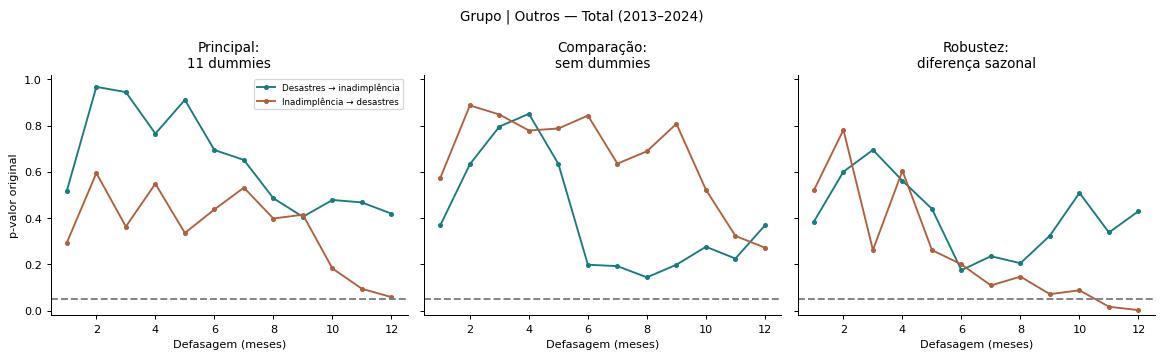

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
48,Principal: 11 dummies,AIC,Desastres → inadimplência,5,0.302121,0.910734,0.964065,1.000000,0.902929,1.996620e-01,138,5,116,5
49,Principal: 11 dummies,AIC,Inadimplência → desastres,5,1.155322,0.335507,0.620820,1.000000,0.424571,4.852046e-02,138,5,116,5
50,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.419744,0.518225,0.837887,1.000000,0.546721,5.393005e-01,142,1,128,1
51,Principal: 11 dummies,BIC,Inadimplência → desastres,1,1.112664,0.293490,0.570002,1.000000,0.360032,2.980261e-01,142,1,128,1
52,Comparação: sem dummies,AIC,Desastres → inadimplência,12,1.099119,0.368632,0.830090,1.000000,0.118571,2.555164e-05,131,12,106,12
53,Comparação: sem dummies,AIC,Inadimplência → desastres,12,1.230561,0.272132,0.541957,1.000000,0.508621,7.396327e-08,131,12,106,12
54,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.810320,0.369583,0.830090,1.000000,0.314317,2.858640e-01,142,1,139,1
55,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.317047,0.574295,0.800250,1.000000,0.612132,5.139932e-01,142,1,139,1
56,Robustez: diferença sazonal,AIC,Desastres → inadimplência,12,1.028598,0.429702,0.830090,1.000000,0.458980,2.858963e-09,119,12,94,12
57,Robustez: diferença sazonal,AIC,Inadimplência → desastres,12,2.876610,0.002036,0.050737,0.306397,0.009810,1.746450e-14,119,12,94,12


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
48,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.756038,4.518526e-02,5.423473e-02,-0.068424,False,3.713280e-17,0.018506,Estacionária: convergente,Conflitante: ambos rejeitam
49,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.756038,4.518526e-02,9.551675e-03,0.150955,False,4.468893e-12,0.032320,Estacionária: convergente,Conflitante: ambos rejeitam
50,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.470832,1.939285e-03,9.640887e-02,-0.042237,False,4.242966e-06,0.502265,Estacionária: convergente,Conflitante: ambos rejeitam
51,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.470832,1.939285e-03,1.397616e-03,0.139224,False,1.744668e-02,0.023728,Estacionária: convergente,Conflitante: ambos rejeitam
52,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.971163,2.586087e-01,1.634015e-04,0.049915,False,1.380223e-20,0.378458,Estacionária: convergente,Conflitante: ambos rejeitam
53,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.971163,2.586087e-01,4.531413e-02,0.083855,False,5.521972e-13,0.699591,Estacionária: convergente,Conflitante: ambos rejeitam
54,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.427564,4.241588e-12,1.078551e-14,0.400967,True,2.515996e-04,0.151836,Estacionária: convergente,Conflitante: ambos rejeitam
55,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.427564,4.241588e-12,2.786854e-04,0.204771,True,4.224556e-10,0.241800,Estacionária: convergente,Conflitante: ambos rejeitam
56,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.967743,7.742286e-03,4.549246e-05,-0.185182,True,2.431587e-01,0.962437,Estacionária: convergente,Estacionária: convergente
57,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.967743,7.742286e-03,1.700186e-04,-0.047696,False,3.327102e-08,0.174595,Estacionária: convergente,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 5, p=0.9107, BH=0.9641, n=138; BIC: lag 1, p=0.5182, BH=0.8379, n=142.

**Comparação: sem dummies** — AIC: lag 12, p=0.3686, BH=0.8301, n=131; BIC: lag 1, p=0.3696, BH=0.8301, n=142.

**Robustez: diferença sazonal** — AIC: lag 12, p=0.4297, BH=0.8301, n=119; BIC: lag 1, p=0.3848, BH=0.8301, n=130.

Na direção principal, 0/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 1 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 10/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

### Grupo | Outros — Pré-pandemia (até jan/2020)

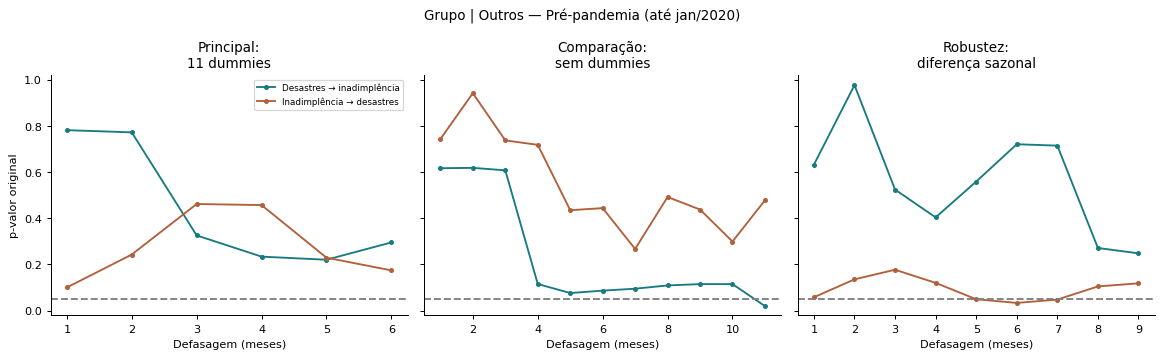

,Especificação,Critério,Direção,Defasagem,F,p,p BH,p BY,p HC3,p HAC12,n efetivo,GL numerador,GL denominador,Ótimo incluindo zero
300,Principal: 11 dummies,AIC,Desastres → inadimplência,4,1.433728,0.233904,0.774190,1.0,0.332168,5.606513e-02,80,4,60,4
301,Principal: 11 dummies,AIC,Inadimplência → desastres,4,0.922054,0.457183,0.730870,1.0,0.689048,5.370776e-02,80,4,60,4
302,Principal: 11 dummies,BIC,Desastres → inadimplência,1,0.077357,0.781743,0.909453,1.0,0.805502,7.775062e-01,83,1,69,1
303,Principal: 11 dummies,BIC,Inadimplência → desastres,1,2.775707,0.100238,0.341391,1.0,0.124433,9.729047e-03,83,1,69,1
304,Comparação: sem dummies,AIC,Desastres → inadimplência,11,2.356752,0.019714,0.273314,1.0,0.076356,1.532441e-08,73,11,50,11
305,Comparação: sem dummies,AIC,Inadimplência → desastres,11,0.978521,0.477863,0.748652,1.0,0.608091,1.140454e-06,73,11,50,11
306,Comparação: sem dummies,BIC,Desastres → inadimplência,1,0.252276,0.616857,0.847699,1.0,0.595563,4.788484e-01,83,1,80,1
307,Comparação: sem dummies,BIC,Inadimplência → desastres,1,0.108134,0.743138,0.896667,1.0,0.764470,7.071108e-01,83,1,80,1
308,Robustez: diferença sazonal,AIC,Desastres → inadimplência,4,1.021165,0.403915,0.830090,1.0,0.327751,2.094498e-04,68,4,59,4
309,Robustez: diferença sazonal,AIC,Inadimplência → desastres,4,1.913135,0.120145,0.364163,1.0,0.028708,3.168069e-04,68,4,59,4


,Especificação,Critério,Direção,Estável,Raiz máxima,Portmanteau p,Ljung–Box p,ACF(12),Pico sazonal,Jarque–Bera p,Breusch–Pagan p,Estacionariedade I,Estacionariedade D
300,Principal: 11 dummies,AIC,Desastres → inadimplência,True,0.856225,1.839144e-02,1.207929e-02,-0.188731,False,0.146916,0.153453,Inconclusiva: nenhum rejeita,Estacionária: convergente
301,Principal: 11 dummies,AIC,Inadimplência → desastres,True,0.856225,1.839144e-02,2.057667e-01,0.053068,False,0.067071,0.063711,Inconclusiva: nenhum rejeita,Estacionária: convergente
302,Principal: 11 dummies,BIC,Desastres → inadimplência,True,0.435839,7.471511e-04,4.819569e-03,-0.073010,False,0.783677,0.971964,Inconclusiva: nenhum rejeita,Estacionária: convergente
303,Principal: 11 dummies,BIC,Inadimplência → desastres,True,0.435839,7.471511e-04,1.313414e-03,0.085634,False,0.954855,0.012762,Inconclusiva: nenhum rejeita,Estacionária: convergente
304,Comparação: sem dummies,AIC,Desastres → inadimplência,True,0.966752,5.999487e-02,2.588768e-03,-0.021417,False,0.892651,0.611441,Inconclusiva: nenhum rejeita,Estacionária: convergente
305,Comparação: sem dummies,AIC,Inadimplência → desastres,True,0.966752,5.999487e-02,6.066339e-03,0.053363,False,0.025263,0.346510,Inconclusiva: nenhum rejeita,Estacionária: convergente
306,Comparação: sem dummies,BIC,Desastres → inadimplência,True,0.448032,3.332040e-07,1.984506e-08,0.363178,True,0.130642,0.778870,Inconclusiva: nenhum rejeita,Estacionária: convergente
307,Comparação: sem dummies,BIC,Inadimplência → desastres,True,0.448032,3.332040e-07,1.454335e-02,0.219680,True,0.002456,0.358566,Inconclusiva: nenhum rejeita,Estacionária: convergente
308,Robustez: diferença sazonal,AIC,Desastres → inadimplência,True,0.818555,1.350391e-02,1.321751e-04,-0.460652,True,0.739478,0.182656,Inconclusiva: nenhum rejeita,Estacionária: convergente
309,Robustez: diferença sazonal,AIC,Inadimplência → desastres,True,0.818555,1.350391e-02,1.306887e-01,-0.158565,False,0.080233,0.281669,Inconclusiva: nenhum rejeita,Estacionária: convergente


**Principal: 11 dummies** — AIC: lag 4, p=0.2339, BH=0.7742, n=80; BIC: lag 1, p=0.7817, BH=0.9095, n=83.

**Comparação: sem dummies** — AIC: lag 11, p=0.01971, BH=0.2733, n=73; BIC: lag 1, p=0.6169, BH=0.8477, n=83.

**Robustez: diferença sazonal** — AIC: lag 4, p=0.4039, BH=0.8301, n=68; BIC: lag 1, p=0.6321, BH=0.8477, n=71.

Na direção principal, 1/6 linhas de critério têm significância nominal e 0/6 permanecem após BH. Na reversa, são 0 nominais e 0 após BH. Linhas AIC/BIC coincidentes não são testes independentes.

Há rejeição do diagnóstico de ruído branco em 10/12 linhas; 5 sinalizam pico residual no lag 12. Esses alertas limitam a leitura dos F clássicos; HC3/HAC são sensibilidades, não reparos da dinâmica.

Neste recorte, a estacionariedade da inadimplência transformada não tem confirmação conjunta. Os testes Granger são exploratórios; a ausência de rejeição do ADF não demonstra não estacionariedade, mas a limitação impede uma conclusão robusta.

Não rejeitar H0 não demonstra ausência de efeito. Rejeitar o teste conjunto tampouco indica sinal positivo, efeito causal estrutural ou validação preditiva fora da amostra.

In [5]:
for key in meta[meta.Nível.isin(['Referência', 'Grupo'])].Chave:
    for periodo in PERIODOS:
        display(Markdown('### '+key+' — '+periodo))
        r=resultados[(resultados.Chave==key)&(resultados.Período==periodo)]
        if r.empty:
            tabela(inviaveis[(inviaveis.Chave==key)&(inviaveis.Período==periodo)])
            continue
        figura_granger(resultados,sensibilidade,key,periodo)
        tabela(r[['Especificação','Critério','Direção','Defasagem','F','p','p BH','p BY','p HC3','p HAC12','n efetivo','GL numerador','GL denominador','Ótimo incluindo zero']])
        tabela(r[['Especificação','Critério','Direção','Estável','Raiz máxima','Portmanteau p','Ljung–Box p','ACF(12)','Pico sazonal','Jarque–Bera p','Breusch–Pagan p','Estacionariedade I','Estacionariedade D']])
        interpretar_granger(resultados,key,periodo)


## Consistência e conclusão

Os indicadores abaixo exigem significância BH para falar em consistência. Mesmo quando há concordância entre períodos, as amostras se sobrepõem. Diagnósticos favoráveis em um único cenário não bastam para um achado geral.

In [6]:
tabela(comparacao[comparacao.Nível.isin(['Referência', 'Grupo'])])

,Chave,Nível,Categoria,Direção,Linhas nominais,Linhas BH,Linhas BY,AIC e BIC significativos no mesmo cenário,Três especificações significativas no mesmo período/critério,Dois períodos significativos na mesma especificação/critério,Linhas BH com diagnósticos favoráveis
0,Grupo | Climatológico,Grupo,Climatológico,Desastres → inadimplência,1,0,0,False,False,False,0
1,Grupo | Climatológico,Grupo,Climatológico,Inadimplência → desastres,4,0,0,False,False,False,0
2,Grupo | Hidrológico,Grupo,Hidrológico,Desastres → inadimplência,2,0,0,False,False,False,0
3,Grupo | Hidrológico,Grupo,Hidrológico,Inadimplência → desastres,1,0,0,False,False,False,0
4,Grupo | Meteorológico,Grupo,Meteorológico,Desastres → inadimplência,2,0,0,False,False,False,0
5,Grupo | Meteorológico,Grupo,Meteorológico,Inadimplência → desastres,8,3,0,False,False,False,0
6,Grupo | Outros,Grupo,Outros,Desastres → inadimplência,1,0,0,False,False,False,0
7,Grupo | Outros,Grupo,Outros,Inadimplência → desastres,1,0,0,False,False,False,0
40,Total nacional,Referência,Total nacional,Desastres → inadimplência,1,0,0,False,False,False,0
41,Total nacional,Referência,Total nacional,Inadimplência → desastres,7,2,0,False,False,False,0


In [7]:
p=resultados[resultados.Direção=='Desastres → inadimplência']
u=p.drop_duplicates(['Período','Chave','Especificação','Direção','Defasagem'])
display(Markdown(f'Na família principal há **{len(u)} hipóteses únicas**, **{int((u.p<.05).sum())} rejeições nominais** e **{int((u["p BH"]<.05).sum())} após BH**. A ampliação não sustenta uma conclusão robusta de precedência dos desastres sobre a inadimplência nas especificações avaliadas. Isso não prova ausência de efeitos locais ou de outros mecanismos.'))


Na família principal há **235 hipóteses únicas**, **29 rejeições nominais** e **0 após BH**. A ampliação não sustenta uma conclusão robusta de precedência dos desastres sobre a inadimplência nas especificações avaliadas. Isso não prova ausência de efeitos locais ou de outros mecanismos.